In [115]:
import json
import os
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely
import seaborn as sns

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

from zipfile import ZipFile

import rioxarray as rxr
import xarray as xr

crs = "EPSG:4326"
#crs = "EPSG:3310"
county_filepath = "/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp"
sb_bbox = [-125, 34.25, -119.0, 38.0]

data_fp_root = "/capstone/wildfire_prep/data"

data_api_url = "https://api.planet.com/data/v1"
orders_api_url = 'https://api.planet.com/compute/ops/orders/v2' 

counties = (
    gpd
    .read_file(county_filepath)
    .to_crs(crs)
    )

sb_county = (
    counties
    .loc[counties["NAME"] == "Santa Barbara"]
    .explode(ignore_index=True)
    .iloc[[0]]
    )

In [6]:
os.path.join(data_fp_root, "PSScene")

'/capstone/wildfire_prep/data/PSScene'

In [ ]:
# declare data path
path = os.path.join(data_fp_root, "PSScene", "/")

# # to store files in a list
# list = []

# # dirs=directories
# for (root, dirs, file) in os.walk(path):
#     for f in file:
#         if 'udm2.tif' in f:
#             list.append(f)
#             print(f)



337-1233_ortho_udm2.tif
342-1232_ortho_udm2.tif
342-1234_ortho_udm2.tif
339-1234_ortho_udm2.tif
339-1237_ortho_udm2.tif
338-1236_ortho_udm2.tif
337-1236_ortho_udm2.tif
343-1232_ortho_udm2.tif
344-1234_ortho_udm2.tif
341-1236_ortho_udm2.tif
343-1236_ortho_udm2.tif
344-1232_ortho_udm2.tif
339-1233_ortho_udm2.tif
339-1235_ortho_udm2.tif
344-1233_ortho_udm2.tif
337-1234_ortho_udm2.tif
340-1235_ortho_udm2.tif
344-1236_ortho_udm2.tif
340-1236_ortho_udm2.tif
341-1233_ortho_udm2.tif
337-1235_ortho_udm2.tif
341-1234_ortho_udm2.tif
342-1236_ortho_udm2.tif
338-1235_ortho_udm2.tif
339-1236_ortho_udm2.tif
341-1235_ortho_udm2.tif
340-1234_ortho_udm2.tif
340-1232_ortho_udm2.tif
342-1235_ortho_udm2.tif
340-1237_ortho_udm2.tif
342-1233_ortho_udm2.tif
341-1237_ortho_udm2.tif
343-1233_ortho_udm2.tif
343-1234_ortho_udm2.tif
342-1237_ortho_udm2.tif
341-1232_ortho_udm2.tif
339-1232_ortho_udm2.tif
338-1232_ortho_udm2.tif
340-1233_ortho_udm2.tif
344-1235_ortho_udm2.tif
343-1235_ortho_udm2.tif
338-1233_ortho_u

In [ ]:
path = "/capstone/wildfire_prep/data/imagery_for_test/wildfire_prep_dataset_test2_psscene_analytic_sr_udm2/one_scene_test/660dd5d1-f657-4476-bc1d-720d1a426ef7"

with ZipFile(f"{path}/output.zip", 'r') as zip: 

    zip.printdir()

    # extracting all the files 
    print('Extracting all the files now...') 
    zip.extractall(path=path) 
    print('Done!') 

In [89]:
udm2_path = "/capstone/wildfire_prep/data/imagery_for_test/wildfire_prep_dataset_test2_psscene_analytic_sr_udm2/one_scene_test/660dd5d1-f657-4476-bc1d-720d1a426ef7/files/PSScene/20220504_175307_95_2442/analytic_8b_sr_udm2/20220504_175307_95_2442_3B_udm2.tif"

test_udm2 = rxr.open_rasterio(udm2_path)
# data_fp_root

In [ ]:
pd_udm2_test = test_udm2.drop_vars("spatial_ref")[5].to_pandas()

In [123]:
test_udm2

<xarray.DataArray (band: 8, y: 9272, x: 13087)> Size: 971MB
[970741312 values with dtype=uint8]
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * x            (x) float64 105kB 6.817e+05 6.817e+05 ... 7.209e+05 7.209e+05
  * y            (y) float64 74kB 3.871e+06 3.871e+06 ... 3.843e+06 3.843e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_IMAGEDESCRIPTION:  {"cloud_model_version": 0}
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 ('clear', 'snow', 'shadow', 'haze_light', 'haz...

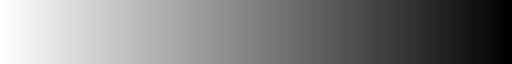

In [120]:
sns.color_palette("blend:white,black", as_cmap=True)

<Axes: xlabel='x', ylabel='y'>

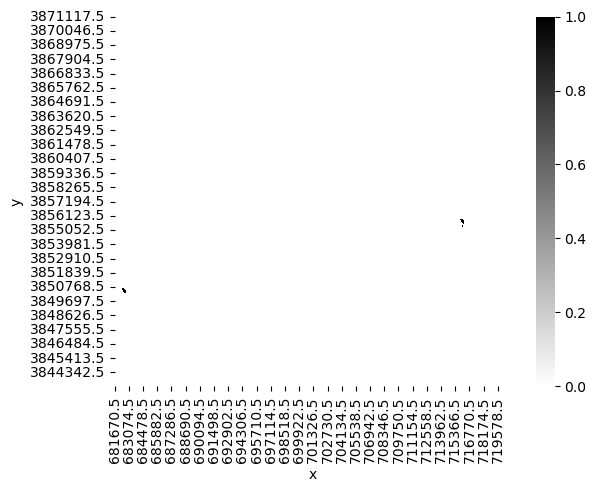

In [ ]:
cmap = sns.color_palette("blend:white,black", as_cmap=True)
udm2_heatmap_clouds = sns.heatmap(pd_udm2_test, 
                           cmap = cmap)
udm2_heatmap_clouds

In [75]:
os.getcwd()

'/capstone/wildfire_prep/josh/data-preparation/code/planet_tests'

In [73]:
help(zip.extractall)

Help on method extractall in module zipfile:

extractall(path=None, members=None, pwd=None) method of zipfile.ZipFile instance
    Extract all members from the archive to the current working
    directory. `path' specifies a different directory to extract to.
    `members' is optional and must be a subset of the list returned
    by namelist(). You can specify the password to decrypt all files
    using 'pwd'.

